<a href="https://colab.research.google.com/github/jawaidaakif01/CNN_PlantDisease/blob/main/DLProject_PlantDiseaseDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install kagglehub

In [4]:
import kagglehub
path = kagglehub.dataset_download("adilmubashirchaudhry/plant-village-dataset")

Using Colab cache for faster access to the 'plant-village-dataset' dataset.


In [5]:
# METHOD : 1 (Traditional Way)

import os
import numpy as np
import tensorflow as tf

train_dir = os.path.join(path, 'PlantVillageDataset/PlantVillage')
categories = os.listdir(train_dir)
if 'PlantVillage' in categories:
  categories.remove('PlantVillage')
print(categories)

X = []
y = []

limit_per_category = 50

print("Starting manual load....")
for index, category in enumerate(categories):
  folder_path = os.path.join(train_dir, category)
  images = os.listdir(folder_path)[:limit_per_category]

  for img_name in images:
    img_path = os.path.join(folder_path, img_name)

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224)) #changed the resolution to later train using MobileNetV2/ResNet
    img_array = tf.keras.utils.img_to_array(img)

    X.append(img_array)
    y.append(index)

X_train = np.array(X)
y_train = np.array(y)

print(X_train.shape)
print(y_train.shape)

X_train = X_train / 255.0
print(f"Pixel range: {np.min(X_train)} to {np.max(X_train)}")

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']
Starting manual load....
(750, 224, 224, 3)
(750,)
Pixel range: 0.0 to 1.0


In [6]:
# METHOD : 2 The "Generator" Way (The Professional Standard)

import os
import tensorflow as tf

data_dir = os.path.join(path, 'PlantVillageDataset/PlantVillage')
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

clean_categories = os.listdir(data_dir)
if 'PlantVillage' in clean_categories:
  clean_categories.remove('PlantVillage')

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset = 'training',
    seed = 123,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_names = clean_categories
)


validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_names = clean_categories
)

class_names = train_ds.class_names
print(len(class_names))

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
15


# Build the Model

In [7]:
from tensorflow.keras import models, layers

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1.0/255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data = validation_ds,
    epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 98s 175ms/step - accuracy: 0.5631 - loss: 1.3726 - val_accuracy: 0.7407 - val_loss: 0.7940
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.8000 - loss: 0.5981 - val_accuracy: 0.8074 - val_loss: 0.5947
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.8681 - loss: 0.3884 - val_accuracy: 0.8604 - val_loss: 0.4498
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.9027 - loss: 0.2859 - val_accuracy: 0.8728 - val_loss: 0.4443
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.9342 - loss: 0.2025 - val_accuracy: 0.8602 - val_loss: 0.4799
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.9486 - loss: 0.1508 - val_accuracy: 0.8813 - val_loss: 0.4545
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9578 - loss: 0.1256 - val_accuracy: 0.8536 - val_loss: 0.6298
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - accuracy: 0.9681 - loss: 0.0926 -

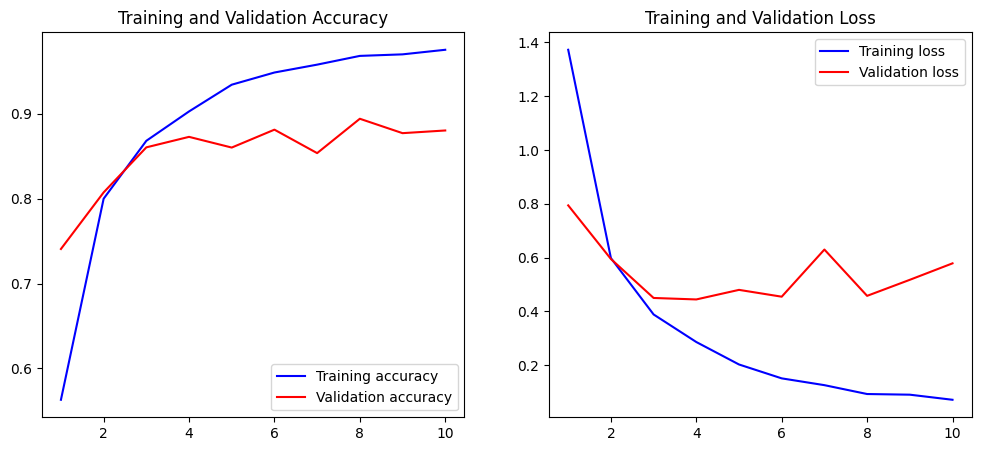

In [9]:
import matplotlib.pyplot as plt

# Extract the data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plotting Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

We are getting an accuracy of 97.53% but the validation accuracy is 88.03% which shows that the model is overfitting.

Let's perform data augmentation and dropout to reduce overfitting

In [11]:
# Model V2 : added data augmentation and dropout to reduce overfitting

from tensorflow.keras import models, layers

num_classes = len(class_names)

model_v2 = models.Sequential([
    layers.RandomFlip('horizontal_and_vertical', input_shape=(224,224,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    layers.Rescaling(1.0/255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_v2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:

history_v2 = model_v2.fit(
  train_ds,
  validation_data=validation_ds,
  epochs=15
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.4467 - loss: 1.7296 - val_accuracy: 0.6705 - val_loss: 1.0331
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.6405 - loss: 1.0953 - val_accuracy: 0.7180 - val_loss: 0.8159
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.6960 - loss: 0.9289 - val_accuracy: 0.6852 - val_loss: 0.9589
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7337 - loss: 0.8149 - val_accuracy: 0.8241 - val_loss: 0.5336
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7657 - loss: 0.7038 - val_accuracy: 0.7928 - val_loss: 0.5846
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.7866 - loss: 0.6356 - val_accuracy: 0.7911 - val_loss: 0.6796
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.8070 - loss: 0.5705 - val_accuracy: 0.8721 - val_loss: 0.3670
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.8175 - loss: 0.5460 - 

# Transfer Learning using MobileNetV2

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

model_tl = models.Sequential([
    layers.RandomFlip('horizontal_and_vertical', input_shape=(224,224,3)),
    layers.RandomRotation(0.1),

    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics = ['accuracy'])

model_tl.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model_tl.fit(
    train_ds,
    validation_data = validation_ds,
    epochs = 10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.7293 - loss: 0.8712 - val_accuracy: 0.8561 - val_loss: 0.4868
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.8454 - loss: 0.4836 - val_accuracy: 0.8832 - val_loss: 0.3831
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.8641 - loss: 0.4143 - val_accuracy: 0.8861 - val_loss: 0.3596
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.8761 - loss: 0.3712 - val_accuracy: 0.8956 - val_loss: 0.3306
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.8761 - loss: 0.3597 - val_accuracy: 0.9043 - val_loss: 0.3046
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.8892 - loss: 0.3353 - val_accuracy: 0.9099 - val_loss: 0.2962
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.8865 - loss: 0.3350 - val_accuracy: 0.9077 - val_loss: 0.2880
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/step - accuracy: 0.8912 - loss: 0.3236 - 

In [18]:
model_tl.save('mobilenet_crop_disease.keras')

In [19]:
print(train_ds.class_names)

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [20]:
import tensorflow as tf
model_check = tf.keras.models.load_model('mobilenet_crop_disease.keras')
print("Model's Internal Order:", train_ds.class_names)

Model's Internal Order: ['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']
